# 実行例5.2 ETL1手書き数字データベースのk最近傍法（kNN法）による識別（p.59図5.9(b)）

- パッケージ類と準備処理は`pima_03-recognition.ipynb`流用。

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using StatsBase
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 学習データおよびテストデータの読み込み

### 1.1 pima.trの読み込み
- `pima_03-recognition.ipynb`流用

In [2]:
# (1)pima.tr.csvのファイルパスを設定する
filepath = joinpath(@__DIR__, "Pima.tr.csv")

# (2)pima.tr.csv（filepath）を読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)データ配列の準備
glu_tr = Int64[]
bmi_tr = Float64[]
onset_tr = Bool[]
n_tr = 0

# (4)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, npreg, glu, bp, skin, bmi, ped, age, type = split(line, ",")
    push!(glu_tr,  parse(Int64, glu))
    push!(bmi_tr,  parse(Float64, bmi))
    push!(onset_tr, strip(type)=="Yes")  # Yesの時に真を設定
    n_tr += 1 
end

println(n_tr)

200


### 1.2 pima.teの読み込み
- `pima_03-recognition.ipynb`流用

In [3]:
# (1)pima.te.csvのファイルパスを設定する
filepath = joinpath(@__DIR__, "Pima.te.csv")

# (2)pima.te.csv（filepath）を読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)データ配列の準備
glu_te = Int64[]
bmi_te = Float64[]
onset_te = Bool[]
n_te = 0

# (4)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, npreg, glu, bp, skin, bmi, ped, age, type = split(line, ",")
    push!(glu_te,  parse(Int64, glu))
    push!(bmi_te,  parse(Float64, bmi))
    push!(onset_te, strip(type)=="Yes")  # Yesの時に真を設定
    n_te += 1
end

println(n_te)

332


#### 1.3 データ型の定義とデータセット作成
- `xset_tr`と`xset_te`はどちらの書き方でもデータセットが作ることができる。
- 数値特徴は単位の取り方による大小が距離計算に大きく影響するので、平均0、分散1に標準化した。

In [4]:
# (1)データの定義
struct pim_x
    glu::Float64
    bmi::Float64
    onset::Bool
end

# (2)データ配列の宣言
xset_tr = pim_x[]
xset_te = pim_x[]
xset_all = pim_x[]

println(typeof(xset_all))

# (3)データセット作成
#xset_tr
for i in 1:n_tr
    push!(xset_tr, pim_x(glu_tr[i], bmi_tr[i], onset_tr[i]))
end
#xset_te
append!(xset_te, [pim_x(glu_te[i], bmi_te[i], onset_te[i]) for i in 1:n_te])
#xset_all
append!(xset_all, xset_tr)
append!(xset_all, xset_te)

# (4)テストデータの件数
N_tr = length(xset_tr)  # 200件
N_te = length(xset_te)  # 332件
N_all = length(xset_all)    #532件

# (5)標準化
#　平均
μ_glu = mean(xset_all[i].glu for i in 1:N_all)
μ_bmi = mean(xset_all[i].bmi for i in 1:N_all)
μ = [μ_glu, μ_bmi]

# 共分散
x_glu = [xset_all[i].glu for i in 1:N_all]
x_bmi = [xset_all[i].bmi for i in 1:N_all]
Σ = cov([x_glu x_bmi])

# 標準偏差
σ = [sqrt(Σ[1, 1]), sqrt(Σ[2, 2])]

# 標準化されたデータの配列を準備
xset_tr_z = pim_x[]
xset_te_z = pim_x[]
xset_all_z = pim_x[]

# 標準化されたデータの配列を作成
for i in 1:N_tr
    glu = (xset_tr[i].glu - μ_glu) / σ[1]
    bmi = (xset_tr[i].bmi - μ_bmi) / σ[2]
    onset = xset_tr[i].onset
    x = (glu, bmi, onset)

    push!(xset_tr_z, pim_x(glu, bmi, onset))
end

for i in 1:N_te
    glu = (xset_te[i].glu - μ_glu) / σ[1]
    bmi = (xset_te[i].bmi - μ_bmi) / σ[2]
    onset = xset_te[i].onset
    x = (glu, bmi, onset)

    push!(xset_te_z, pim_x(glu, bmi, onset))
end

append!(xset_all_z, xset_tr_z)
append!(xset_all_z, xset_te_z)


Vector{pim_x}


532-element Vector{pim_x}:
 pim_x(-1.1300306396134256, -0.3909581449241569, false)
 pim_x(2.386186184270633, -1.1321177584011168, true)
 pim_x(-1.4203604691084397, 0.4228641757564266, false)
 pim_x(1.4184200859539198, 2.181301690084117, false)
 pim_x(-0.4525943707917262, -0.943194719671696, false)
 pim_x(-0.7751830702306307, 0.39379909287497783, true)
 pim_x(-1.226807249445097, 0.20487605414555596, false)
 pim_x(2.321668444382852, -1.0158574268753195, false)
 pim_x(0.6764660772444394, -0.07124223322821335, false)
 pim_x(0.22484189802997318, 1.5128047838107799, true)
 ⋮
 pim_x(-0.0009701915772599561, 0.8879055018596178, false)
 pim_x(-0.4203355008478358, -1.0013248854345946, false)
 pim_x(1.934562005056167, 1.5128047838107799, true)
 pim_x(0.22484189802997318, 0.5245919658415, true)
 pim_x(-1.0655128997256447, -0.6525438908572018, false)
 pim_x(1.5797144356733719, 1.6145325738958534, true)
 pim_x(-0.6461475904550689, 0.0014204739754101962, false)
 pim_x(-0.0009701915772599561, -0.972259

### 2. kNN法のための関数

#### 2.1 鋳型との距離の計算関数

In [5]:
# (1)鋳型との距離の計算関数
function distance(x::pim_x, xset::Vector{pim_x})
    # 第1引数 : テストデータ, 第2引数 : 
    distances = [sqrt((Float64(x.glu) - Float64(xset[i].glu))^2 + (x.bmi - xset[i].bmi)^2) for i in 1:length(xset)]

    return distances
end

# (2)計算関数のテスト
x = xset_te_z[1]
xset = xset_tr_z

distances = distance(x, xset)
@show(typeof(distances))

distances[2]

typeof(distances) = Vector{Float64}


1.9556697514109225

In [6]:
# (1)kNN識別関数
function kNN_method(x::pim_x, xset::Vector{pim_x}, k::Int64)
    # 第1引数 : テストデータ, 第2引数 : 全学習データ,第3引数 : kNNの鋳型の数
    
    # 全学習データとの距離を計算
    distances = distance(x, xset)  # Vector{Float64}

    # 距離が小さい順のインデックス
    sorted_idx = sortperm(distances)

    # 上位k件のクラスラベルを取得
    nearest_labels = [xset[sorted_idx[i]].onset for i in 1:k]

    # 多数決
    predict = argmax(countmap(nearest_labels))  # Bool

    return predict
end

# (2)識別関数のテスト
x = xset_te_z[1]
xset = xset_tr_z
k = 1

predict = kNN_method(x, xset, k)

false

#### 1.2 学習/テストデータ分割法ごとに誤識別率を測定（p.13～16）
- ホールドアウト法 : 200個の学習データ（`xset_tr`）と332個のテストデータ（`xset_te`）とする。
- 一つ抜き法（ジャックナイフ法） : 532個の全データ（`xet_all`）を使用する。

In [7]:
# (1)ホールドアウト法によるkNN識別
function kNN_holdout(set_train::Vector{pim_x}, set_test::Vector{pim_x}, k::Int64)
    # 第1引数 : 学習データセット, 第2引数 : テストデータセット, 第3引数 : kNNの鋳型の数

    # テストデータ件数
    N = length(set_test)

    # 全学習データでkNN識別実施    
    # 誤識別件数の初期化
    error = 0
    # 誤識別インデックス配列の型宣言
    error_idx = []    
    # テストデータの全件識別
    for i in 1:N
        # x : テストデータ
        x_test = set_test[i]
        # 識別
        predict = kNN_method(x_test, set_train, k)
        # 判定
        judge = Bool(predict == x_test.onset)        
        # エラー件数の追加
        !judge && (error += 1)  # 短絡評価&&
        # エラーのインデックスを配列に追加
        !judge && push!(error_idx, i)
    end

    error_rate = error / N

    return (error, error_rate, error_idx)
end

# (2)一つ抜き法によるkNN識別
function kNN_jackknife(set_all::Vector{pim_x}, k::Int64)
    # 第1引数 : 全データセット, 第2引数 : kNNの鋳型の数

    # 全データ件数
    N = length(set_all)

    # 全データから1つずつ抜き出し残りのデータとkNN識別実施
    # 誤識別件数の初期化
    error = 0
    # 誤識別インデックス配列の型宣言
    error_idx = []
    # テストデータの全件識別
    for i in 1:N
        # x : テストデータ
        x_test = set_all[i]
        # 学習データ
        set_train = set_all[setdiff(1:N, i)]
        # 識別
        predict = kNN_method(x_test, set_train, k)
        # 判定
        judge = Bool(predict == x_test.onset)
        # エラー件数の追加
        !judge && (error += 1)  # 短絡評価&&
        # エラーのインデックスを配列に追加
        !judge && push!(error_idx, i)
    end

    error_rate = error / N

    return (error, error_rate, error_idx)
end

kNN_jackknife (generic function with 1 method)

【テスト】各手法による誤識別率

In [8]:
# k = 1
# error_rate_holdout = kNN_holdout(xset_tr, xset_te, k)[2]
# error_rate_jackknife = kNN_jackknife(xset_all, k)[2]
# println("ホールドアウト：", round(error_rate_holdout*100, digits=2), "%, ジャックナイフ：", round(error_rate_jackknife*100, digits=2), "%")

### 2. kの違いによる誤り率の変化
- kを変化させながら20回試行した場合の誤り率の平均を取得する。

#### 2.1 20回の試行を行い平均を取る
- 計算を並列化する。
    1. `Threads.@threads`でCPUのスレッドによる並列計算を行う。
    2. 結果を格納する`Vector`を準備する（並列化で事前に型とサイズを確保する）。`[]`だと型が`Any`でサイズも未確定なので使えない。

In [9]:
# (1)p.60図5.9(b)の条件に合わせた20回の試行の平均
function trial_20times(set_train::Vector{pim_x}, set_test::Vector{pim_x}, set_all::Vector{pim_x}, k::Int64)
    # 第1引数 : 学習データセット, 第2引数 : テストデータセット, 第3引数 : 全データセット, 第4引数 : kNNの鋳型の数
    # 20回試行の誤識別率の配列準備
    rate_holdout = Vector{Float64}(undef, 20)
    rate_jackknife = Vector{Float64}(undef, 20)
    @show(Threads.nthreads())    # スレッド数の表示
    Threads.@threads for i in 1:20
        println("i=$i, thread=$(Threads.threadid())") # 使用スレッドの表示
        # ホールドアウト法              
        rate_holdout[i] = kNN_holdout(set_train, set_test, k)[2]
        #ジャックナイフ法
        rate_jackknife[i] = kNN_jackknife(set_all, k)[2]
    end

    return (rate_holdout, rate_jackknife)
end

trial_20times (generic function with 1 method)

#### 2.2 kを変化させた時の誤識別率の測定
- kを奇数で取り、多数決で同数を防ぐ。
- 例えば19までの奇数の配列を作るには
    1. `k = (1:10) .* 2 .- 1` : `[1:10] .* 2 .- 1`は前半でRange を1要素に包んだ配列`[2:20]`ができるだけなのでエラー。
    2. `k = collect(1:2:19)`

In [10]:
# (1)kの配列
k = collect(1:2:121)

# (2)kを変化させて誤識別率を測定
cal_time = @time results = [trial_20times(xset_tr_z, xset_te_z, xset_all_z, i) for i in k]
rate_holdout   = [r[1] for r in results]
rate_jackknife = [r[2] for r in results]

println(cal_time)

Threads.nthreads() = 16
i=16, thread=2
i=9, thread=10
i=3, thread=16
i=10, thread=6
i=14, thread=7
i=11, thread=3
i=7, thread=12
i=19, thread=11
i=18, thread=13
i=17, thread=5
i=15, thread=17
i=1, thread=8
i=13, thread=14
i=12, thread=9
i=5, thread=4
i=20, thread=15
i=4, thread=16
i=6, thread=4
i=8, thread=12
i=2, thread=8
Threads.nthreads() = 16
i=1, thread=2
i=11, thread=4
i=17, thread=2
i=3, thread=4
i=9, thread=2
i=13, thread=3
i=15, thread=6
i=19, thread=4
i=20, thread=3
i=12, thread=4
i=10, thread=2
i=18, thread=2
i=7, thread=4
i=14, thread=2
i=16, thread=3
i=5, thread=4
i=4, thread=3
i=2, thread=6
i=8, thread=14
i=6, thread=13
Threads.nthreads() = 16
i=1, thread=2
i=13, thread=13
i=15, thread=6
i=3, thread=3
i=14, thread=6
i=17, thread=2
i=12, thread=12
i=19, thread=12
i=20, thread=13
i=10, thread=2
i=11, thread=3
i=7, thread=3
i=18, thread=9
i=9, thread=12
i=5, thread=4
i=16, thread=11
i=4, thread=4
i=2, thread=13
i=8, thread=7
i=6, thread=5
Threads.nthreads() = 16
i=1, thread=

#### 2.3 誤識別率の20回平均のプロット

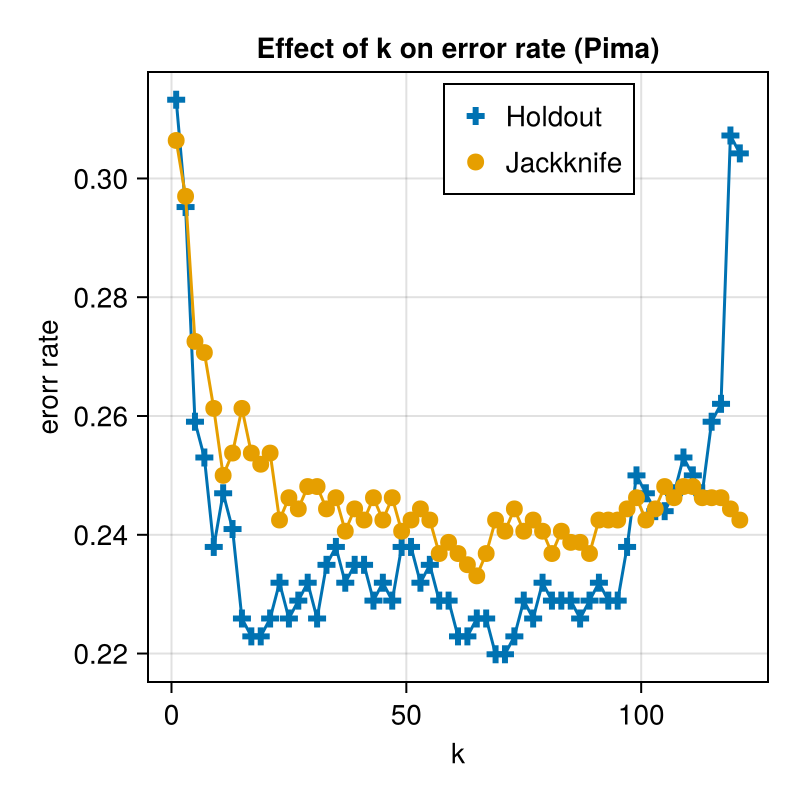

In [11]:
# (1)kごとの20回の誤識別率平均
μ_rate_holdout = [mean(rate_holdout[j]) for j in 1:length(k)]
μ_rate_jackknife = [mean(rate_jackknife[j]) for j in 1:length(k)]

# (2)誤識別率平均のプロット
fig = Figure(size = (400, 400))
ax = CairoMakie.Axis(fig[1, 1],
    xlabel="k",
    ylabel="erorr rate",
    title="Effect of k on error rate (Pima)")
lines!(ax, k, μ_rate_holdout)
scatter!(ax, k, μ_rate_holdout, marker=:cross, markersize=12, label="Holdout")
lines!(ax, k, μ_rate_jackknife)
scatter!(ax, k, μ_rate_jackknife, marker=:circle, markersize=12, label="Jackknife")
axislegend(ax, position=:rt, halign=0.7)

save("pima_kNN_error_rate.png", fig)
fig